In [3]:
!pip install prince==0.7.1

In [4]:
# Install packages if not already installed
#!pip install pandas numpy scikit-learn matplotlib seaborn

# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import prince
sns.set_style("whitegrid")

from sklearn.cluster import KMeans
from scipy.stats import chi2_contingency
from scipy.stats import chi2_contingency
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SelectKBest, chi2, f_classif, mutual_info_classif
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix


In [41]:
df = pd.read_excel('/content/south_asian_sugarcane_large.xlsx')

# View structure and summary
print(df.info())
print(df.describe())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Year                 50000 non-null  int64  
 1   Country              50000 non-null  object 
 2   ActionWater          50000 non-null  object 
 3   WaterType            50000 non-null  object 
 4   Class_cane           50000 non-null  object 
 5   Epidemic             50000 non-null  object 
 6   YieldOldGrade        50000 non-null  object 
 7   Type_Cane            50000 non-null  object 
 8   GrooveWide           50000 non-null  object 
 9   FertilizerType       50000 non-null  object 
 10  TypeSoil             50000 non-null  object 
 11  Fertilizer           50000 non-null  object 
 12  TargetOldGrade       50000 non-null  object 
 13  Yield                50000 non-null  float64
 14  Area_Remain          50000 non-null  float64
 15  ContractsArea        50000 non-null 

### Recategorize the 'Yield' variable into two categories

In [42]:
yield_data = df[['Yield']]
kmeans = KMeans(n_clusters=2, random_state=42)
kmeans.fit(yield_data)
cluster_labels = kmeans.labels_
df['Yield_Category'] = cluster_labels
print(df['Yield_Category'].value_counts())  # See the distribution of categories

Yield_Category
1    25118
0    24882
Name: count, dtype: int64


In [43]:
df['Yield_Category'] = np.where(df['Yield_Category'] == 0, 'Low', 'High')

In [189]:
#Convert GrooveWide to Numeric
# Remove ' cm' and convert to numeric
#df['GrooveWide'] = df['GrooveWide'].str.replace(' cm', '').astype(float)


In [190]:
# Split 'Fertilizer' into N, P, K columns
#fertilizer_split = df['Fertilizer'].str.split('-', expand=True)
#df['N'] = pd.to_numeric(fertilizer_split[0], errors='coerce')
#df['P'] = pd.to_numeric(fertilizer_split[1], errors='coerce')
#df['K'] = pd.to_numeric(fertilizer_split[2], errors='coerce')


In [44]:
# Create a new column 'YearBin' representing decades
df['YearBin'] = pd.cut(df['Year'],
                       bins=range(1970, 2031, 10),
                       labels=[f"{i}s" for i in range(1970, 2030, 10)],
                       right=False)
#ncode 'YearBin'
le_yearbin = LabelEncoder()
df['YearBin'] = le_yearbin.fit_transform(df['YearBin'].astype(str))


In [9]:
#df['Year'] = df['Year'].astype(str)

In [45]:
df = df.drop(['Year','Yield'], axis=1)

In [46]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Country              50000 non-null  object 
 1   ActionWater          50000 non-null  object 
 2   WaterType            50000 non-null  object 
 3   Class_cane           50000 non-null  object 
 4   Epidemic             50000 non-null  object 
 5   YieldOldGrade        50000 non-null  object 
 6   Type_Cane            50000 non-null  object 
 7   GrooveWide           50000 non-null  object 
 8   FertilizerType       50000 non-null  object 
 9   TypeSoil             50000 non-null  object 
 10  Fertilizer           50000 non-null  object 
 11  TargetOldGrade       50000 non-null  object 
 12  Area_Remain          50000 non-null  float64
 13  ContractsArea        50000 non-null  float64
 14  YieldGrade           50000 non-null  object 
 15  FarmerContractGrade  50000 non-null 

In [12]:
duplicated_rows = df.duplicated().sum()
print(duplicated_rows)

0


In [13]:
# Check unique categories for all categorical variables
unique_categories = {col: df[col].unique() for col in df.select_dtypes(include=['object', 'category']).columns}
print(unique_categories)


{'Country': array(['India', 'Bangladesh', 'Nepal', 'Pakistan', 'Sri Lanka'],
      dtype=object), 'ActionWater': array(['Water pour', 'Rain'], dtype=object), 'WaterType': array(['Rain', 'Natural canal', 'Groundwater'], dtype=object), 'Class_cane': array(['2nd ratoon cane', '3rd ratoon cane', '1st ratoon cane'],
      dtype=object), 'Epidemic': array(['Herbicide', 'Preemergent'], dtype=object), 'YieldOldGrade': array(['Grade 3', 'Grade 2', 'Grade 1'], dtype=object), 'Type_Cane': array(['LK92-11', 'K84-200', 'Khonkean3', 'K99-72'], dtype=object), 'GrooveWide': array(['150 cm', '120 cm', '140 cm', '130 cm'], dtype=object), 'FertilizerType': array(['Organic', 'Chemical'], dtype=object), 'TypeSoil': array(['Silty clay', 'Loam', 'Ferus soil'], dtype=object), 'Fertilizer': array(['25-07-2007', '16-16-16', '15-15-15', '46-0-0'], dtype=object), 'TargetOldGrade': array(['Grade 1', 'Grade 3', 'Grade 2'], dtype=object), 'YieldGrade': array(['Grade 2', 'Grade 3', 'Grade 1'], dtype=object), 'FarmerC

In [14]:
count = (df['Fertilizer'] == '25-07-2007').sum()
print("Count of '25-07-2007' in Fertilizer column:", count)


Count of '25-07-2007' in Fertilizer column: 12473


In [15]:
df['Fertilizer'] = df['Fertilizer'].replace('25-07-2007', '25-7-7')

In [16]:
df['Fertilizer'].value_counts()

,count
Fertilizer,
16-16-16,12531
15-15-15,12500
46-0-0,12496
25-7-7,12473


In [17]:
# Identify categorical variables
categorical_vars = df.select_dtypes(include=['object','category']).columns

# 1. Low Variance Categories
for col in categorical_vars:
    counts = df[col].value_counts(normalize=True)
    if counts.iloc[0] > 0.95:
        print(f"'{col}' has a dominant category: {counts.index[0]} with {counts.iloc[0]*100:.2f}%")

# 2. Redundant Variables
# Compute correlation matrix for numerical encoding of categorical variables
# This is a placeholder; actual implementation requires encoding categorical variables numerically

# 3. Irrelevant Variables
# Chi-square test between each categorical variable and the target
target = 'Yield_Category'
for col in categorical_vars:
    if col != target:
        contingency_table = pd.crosstab(df[col], df[target])
        chi2, p, dof, ex = chi2_contingency(contingency_table)
        if p > 0.05:
            print(f"'{col}' is not significantly associated with '{target}' (p-value: {p:.4f})")

# 4. High Cardinality with Sparse Data
for col in categorical_vars:
    unique_vals = df[col].nunique()
    if unique_vals > 10:
        print(f"'{col}' has high cardinality: {unique_vals} unique categories")

'Country' is not significantly associated with 'Yield_Category' (p-value: 0.1585)
'ActionWater' is not significantly associated with 'Yield_Category' (p-value: 0.7804)
'WaterType' is not significantly associated with 'Yield_Category' (p-value: 0.4555)
'Class_cane' is not significantly associated with 'Yield_Category' (p-value: 0.1815)
'Epidemic' is not significantly associated with 'Yield_Category' (p-value: 0.5976)
'YieldOldGrade' is not significantly associated with 'Yield_Category' (p-value: 0.8194)
'Type_Cane' is not significantly associated with 'Yield_Category' (p-value: 0.7912)
'GrooveWide' is not significantly associated with 'Yield_Category' (p-value: 0.8793)
'FertilizerType' is not significantly associated with 'Yield_Category' (p-value: 0.3612)
'TypeSoil' is not significantly associated with 'Yield_Category' (p-value: 0.9079)
'Fertilizer' is not significantly associated with 'Yield_Category' (p-value: 0.2759)
'TargetOldGrade' is not significantly associated with 'Yield_Categ

In [18]:
from sklearn.model_selection import train_test_split

# Split the data (80% train, 20% test)
train_data, test_data = train_test_split(df, test_size=0.2, random_state=123)

# Confirm number of rows in training set
print("Number of rows in training data:", len(train_data))


Number of rows in training data: 40000


In [217]:
from google.colab import files

# Save train_data to CSV
train_data.to_csv('train_data.csv', index=False)
files.download('train_data.csv')

# Save test_data to CSV
test_data.to_csv('test_data.csv', index=False)
files.download('test_data.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### EDA

### Univariate Analyisis

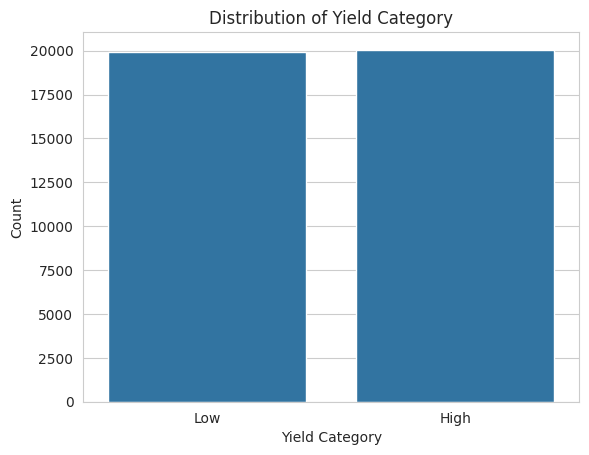

In [19]:
#Distribution of the Target Variable ('Yield_Category')
sns.countplot(x='Yield_Category', data=train_data)
plt.title('Distribution of Yield Category')
plt.xlabel('Yield Category')
plt.ylabel('Count')
plt.show()


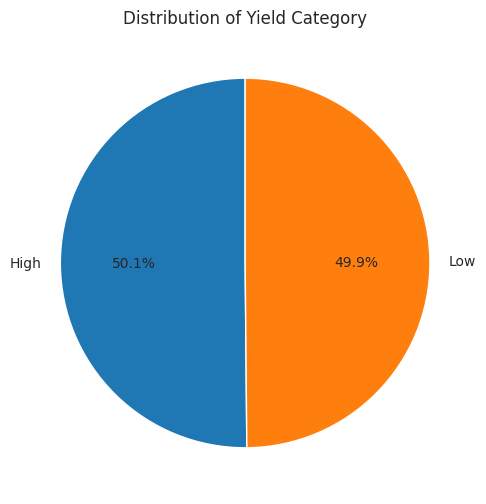

In [39]:
# Count the occurrences of each category
yield_counts = train_data['Yield_Category'].value_counts()

# Create the pie chart
plt.figure(figsize=(6, 6))  # Adjust figure size if needed
plt.pie(yield_counts, labels=yield_counts.index, autopct='%1.1f%%', startangle=90)
plt.title('Distribution of Yield Category')
plt.show()

In [20]:
# Select columns with object or category data types
categorical_columns = train_data.select_dtypes(include=['object', 'category']).columns


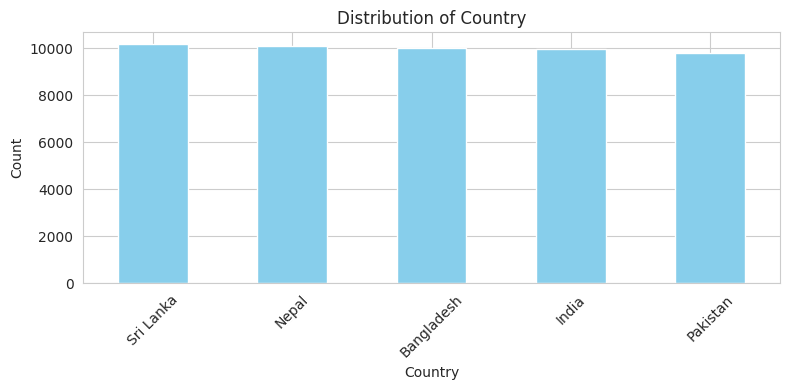

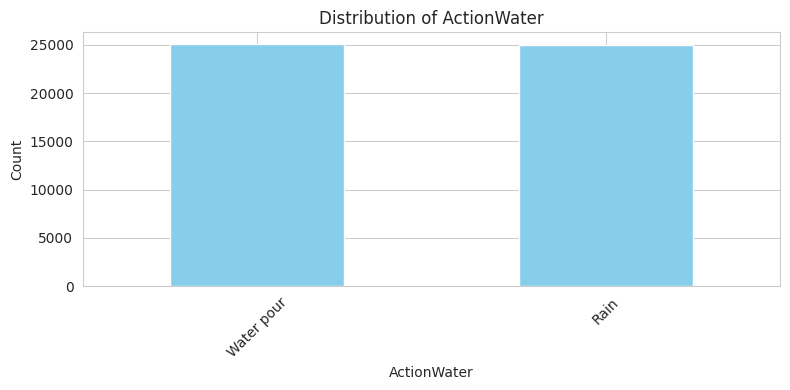

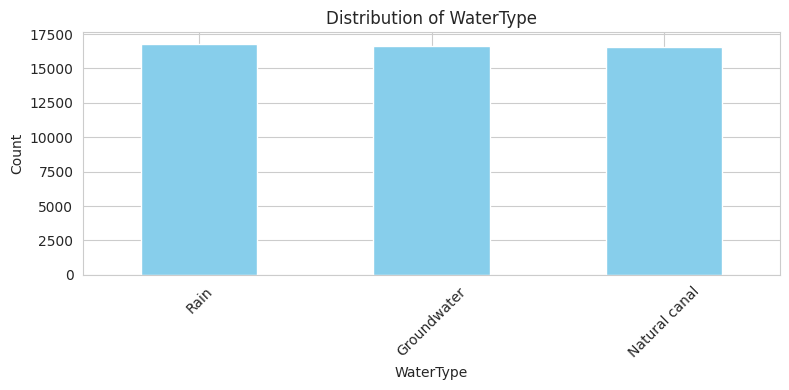

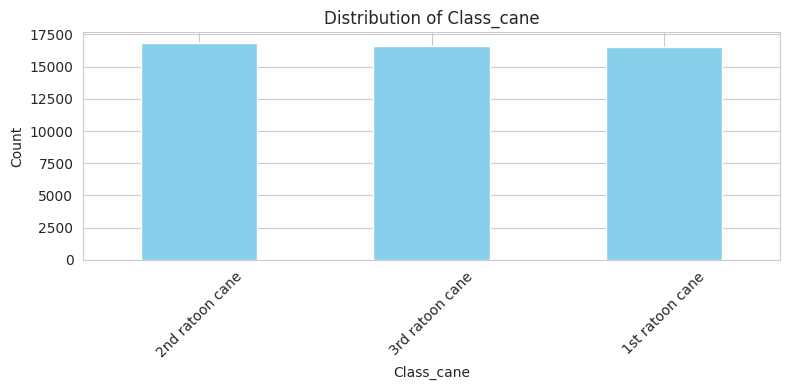

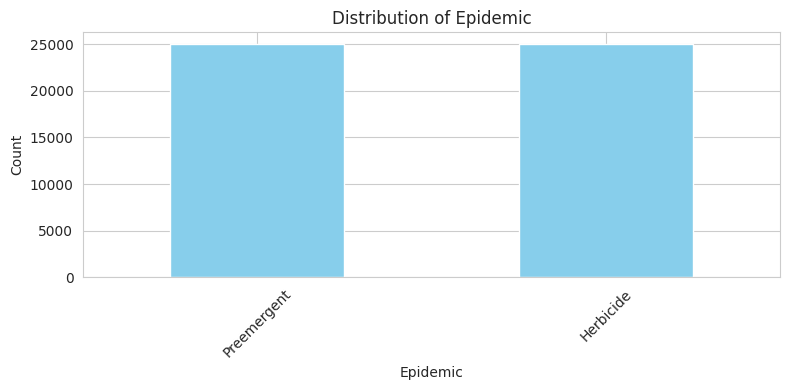

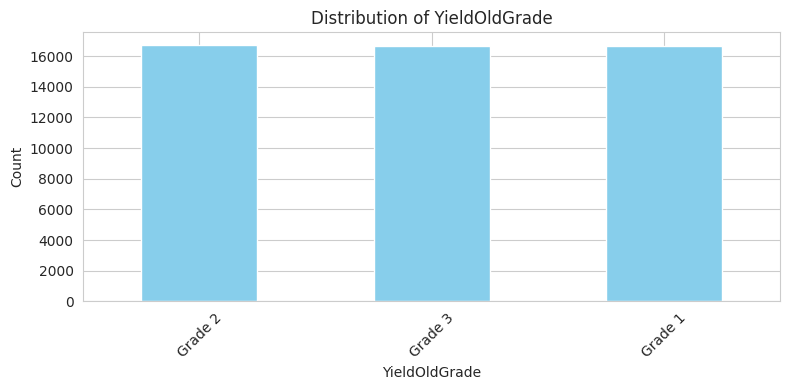

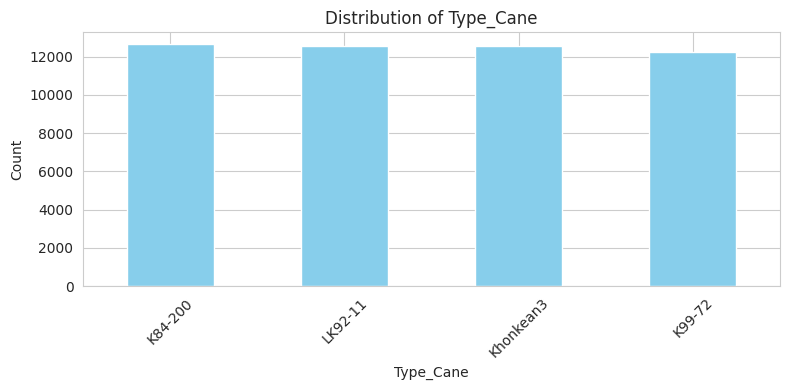

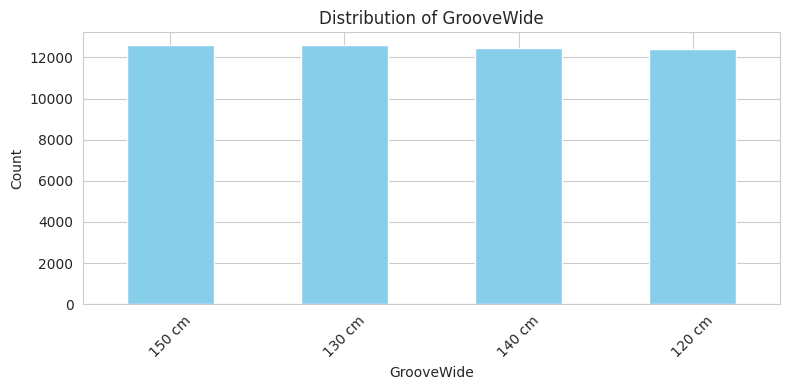

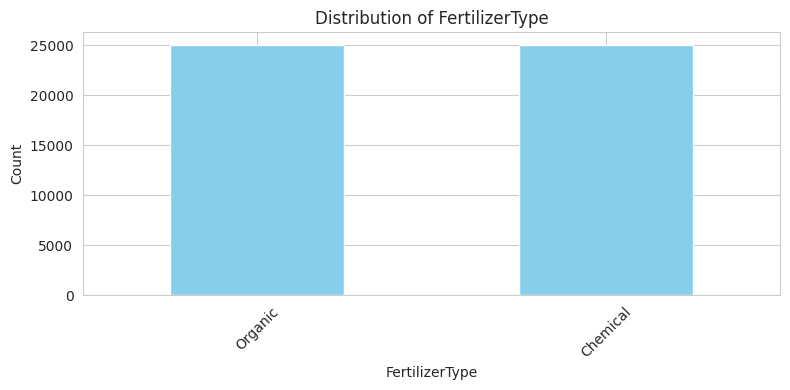

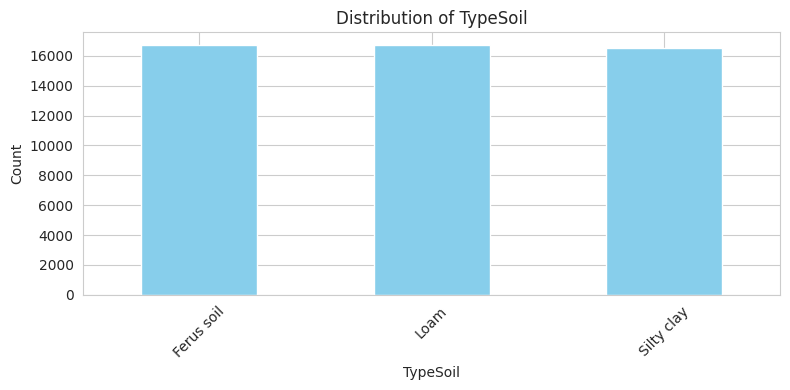

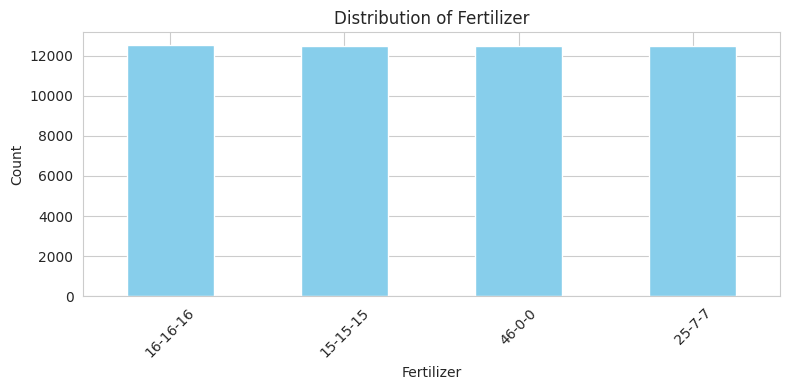

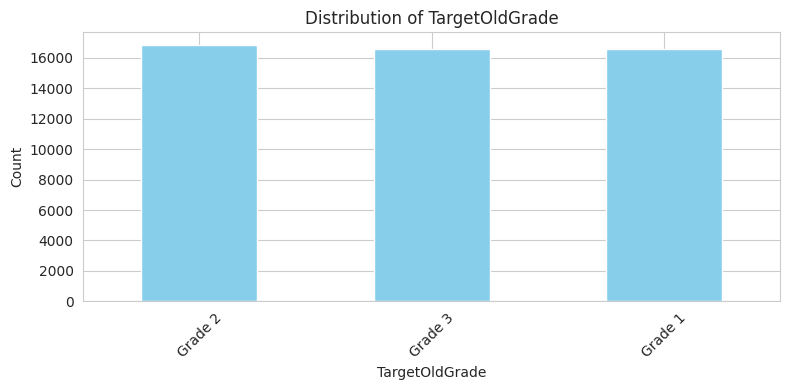

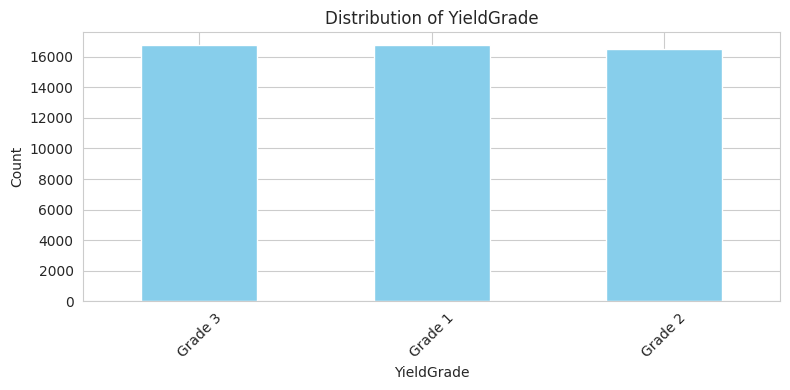

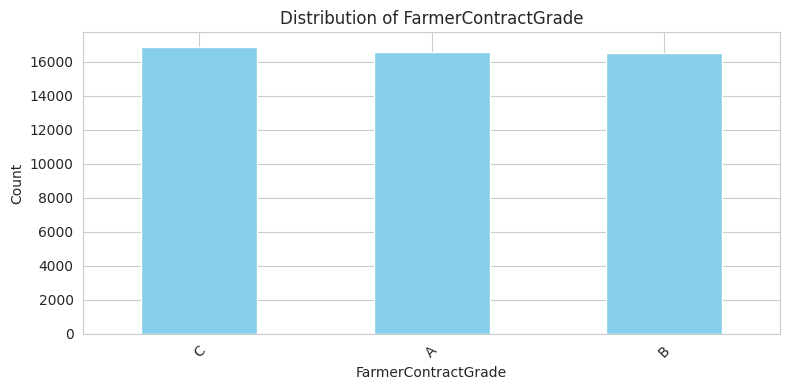

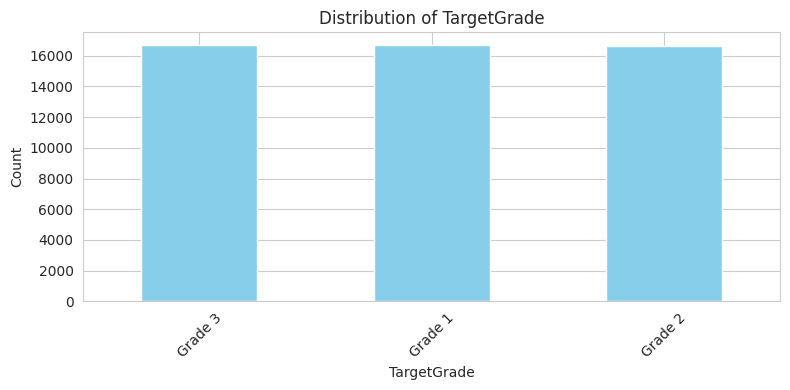

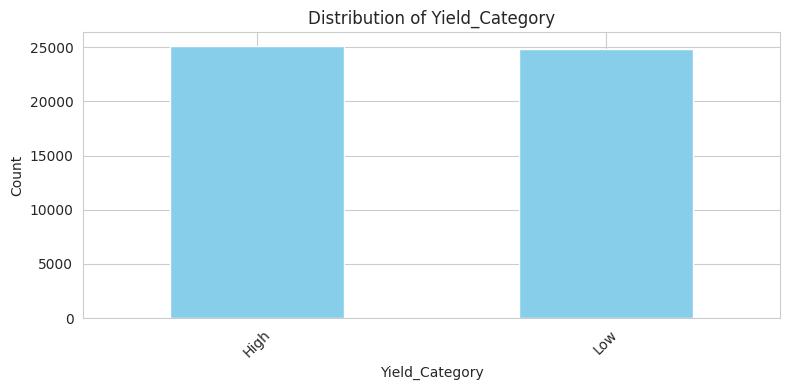

In [21]:
# Iterate through each categorical column and plot
for col in categorical_columns:
    plt.figure(figsize=(8, 4))
    df[col].value_counts().plot(kind='bar', color='skyblue')
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


In [22]:
numerical_columns = train_data.select_dtypes(include=['int64','float64']).columns


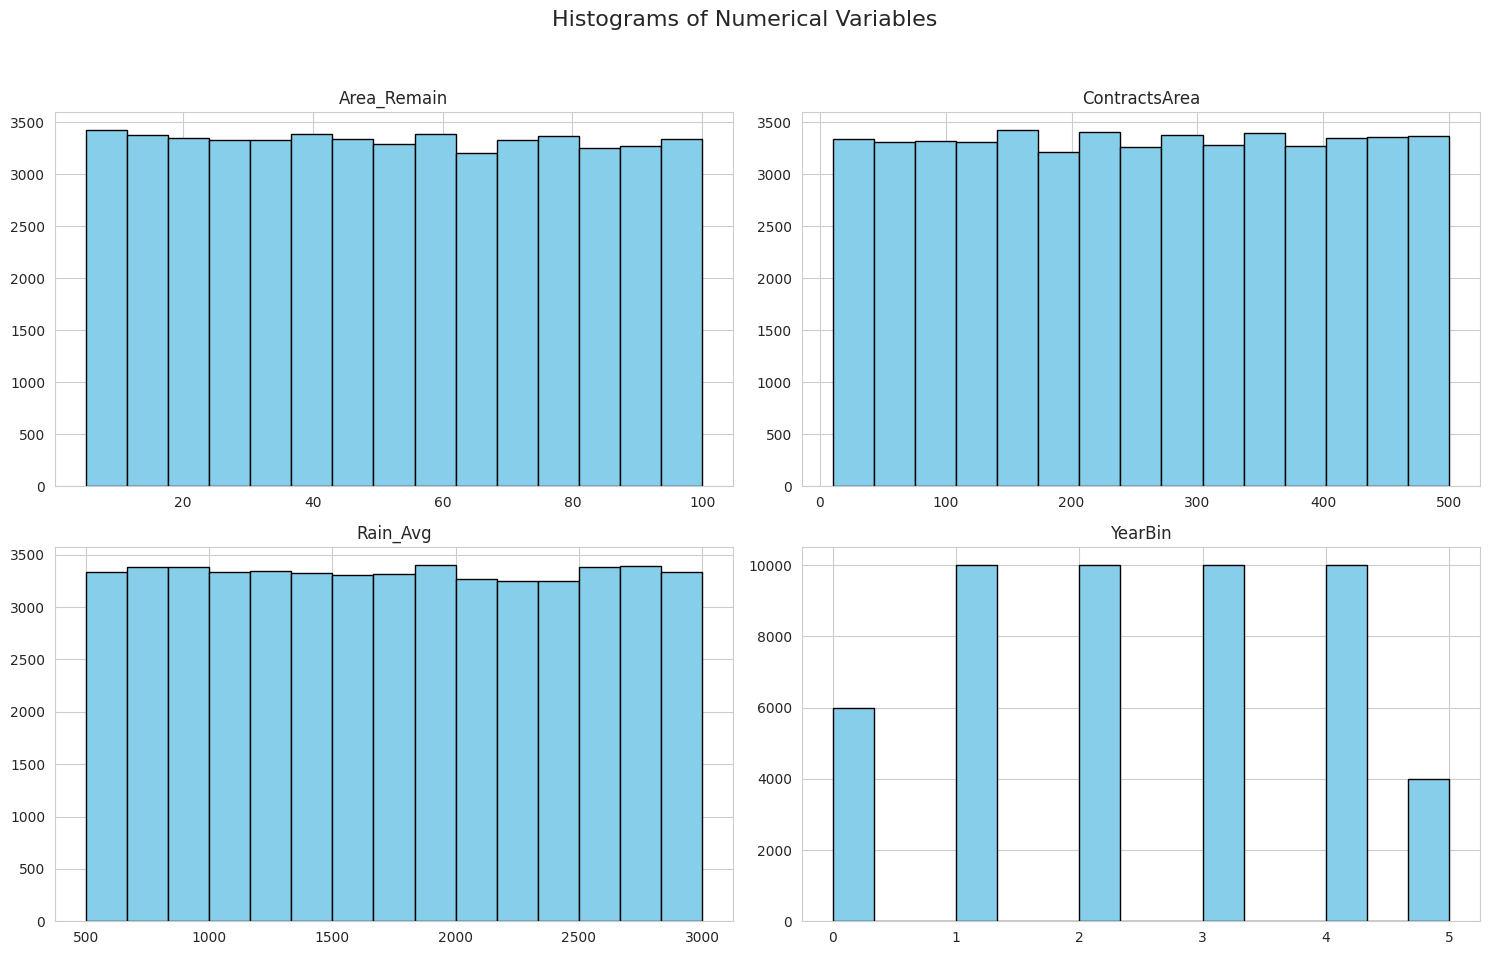

In [23]:
# Create histograms for all numerical columns
df[numerical_columns].hist(bins=15, figsize=(15, 10), color='skyblue', edgecolor='black')
plt.suptitle('Histograms of Numerical Variables', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


In [94]:
# Boxplots for N, P, K against YieldGrade
#for nutrient in ['N', 'P', 'K']:
#    sns.boxplot(x='Yield_Category', y=nutrient, data=train_data)
#    plt.title(f'{nutrient} Levels by Yield_Category')
#    plt.xlabel('Yield Category')
#    plt.ylabel(f'{nutrient} Percentage')
#    plt.show()


### Bivariate Analysis

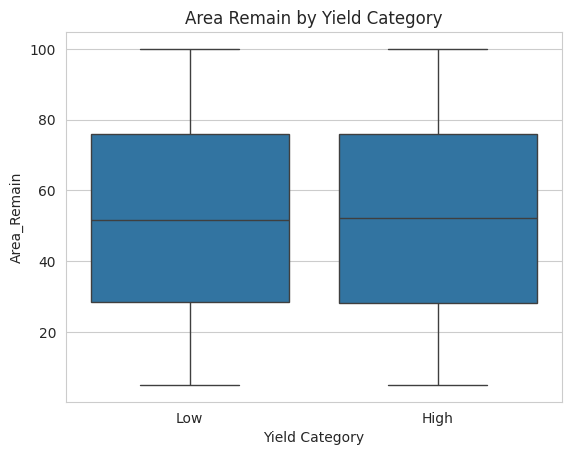

In [24]:
# Area_Remain by YieldCategory
sns.boxplot(x='Yield_Category', y='Area_Remain', data=train_data)
plt.title('Area Remain by Yield Category')
plt.xlabel('Yield Category')
plt.ylabel('Area_Remain')
plt.show()



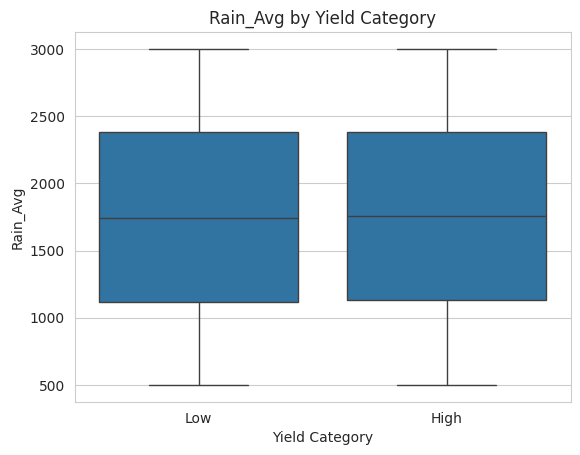

In [25]:
# Rain_Avg by YieldCategory
sns.boxplot(x='Yield_Category', y='Rain_Avg', data=train_data)
plt.title('Rain_Avg by Yield Category')
plt.xlabel('Yield Category')
plt.ylabel('Rain_Avg')
plt.show()


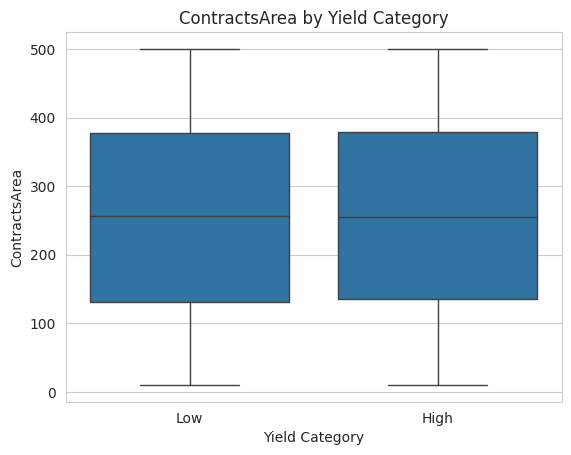

In [26]:
# ContractsArea by YieldCategory
sns.boxplot(x='Yield_Category', y='ContractsArea', data=train_data)
plt.title('ContractsArea by Yield Category')
plt.xlabel('Yield Category')
plt.ylabel('ContractsArea')
plt.show()

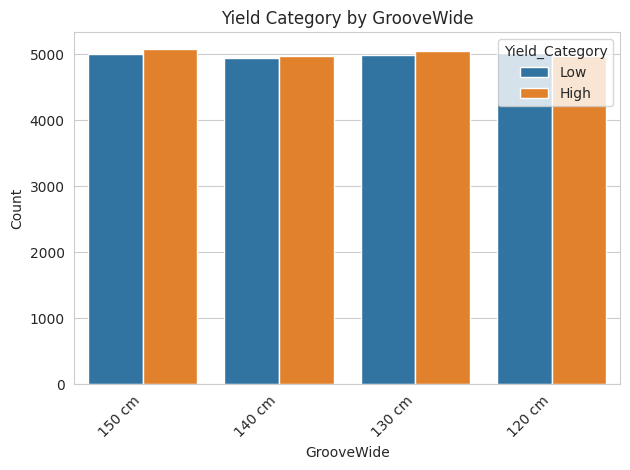

In [27]:
sns.countplot(x='GrooveWide', hue='Yield_Category', data=train_data)
plt.title('Yield Category by GrooveWide')
plt.xlabel('GrooveWide')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels for better readability
plt.tight_layout()
plt.show()

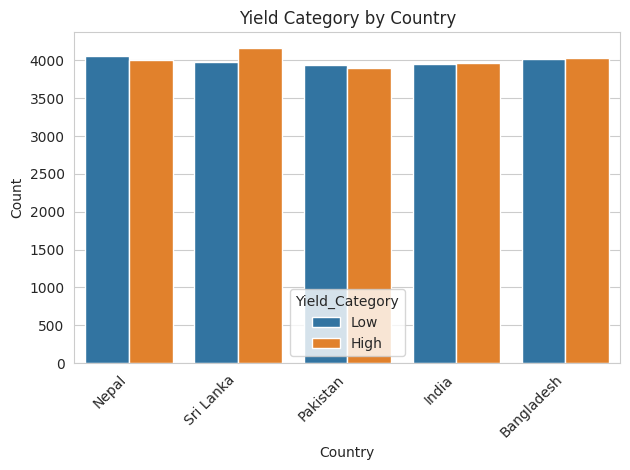

In [28]:
sns.countplot(x='Country', hue='Yield_Category', data=train_data)
plt.title('Yield Category by Country')
plt.xlabel('Country')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels for better readability
plt.tight_layout()
plt.show()

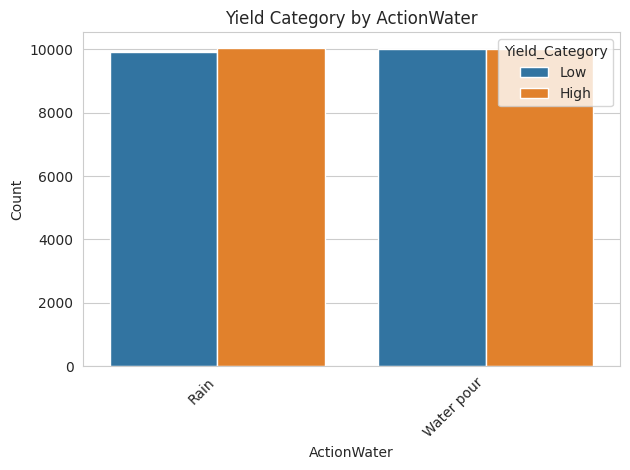

In [29]:
sns.countplot(x='ActionWater', hue='Yield_Category', data=train_data)
plt.title('Yield Category by ActionWater')
plt.xlabel('ActionWater')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

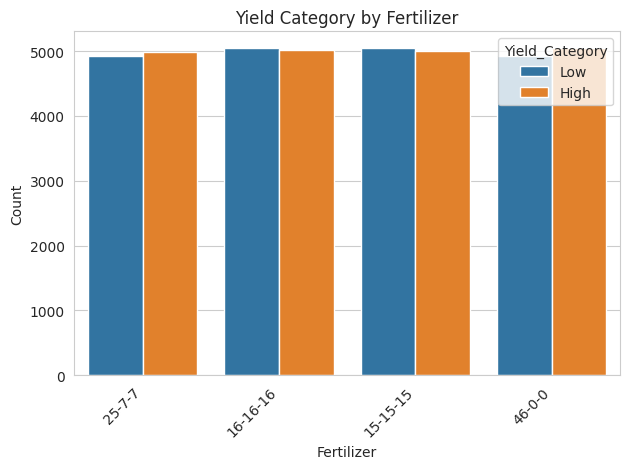

In [30]:
sns.countplot(x='Fertilizer', hue='Yield_Category', data=train_data)
plt.title('Yield Category by Fertilizer')
plt.xlabel('Fertilizer')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [103]:
# GrooveWide by YieldGrade
#sns.violinplot(x='YieldGrade', y='GrooveWide', data=train_data)
#plt.title('GrooveWide Distribution by Yield Grade')
#plt.xlabel('Yield Grade')
#plt.ylabel('GrooveWide')
#plt.show()

### Correlation between Variables

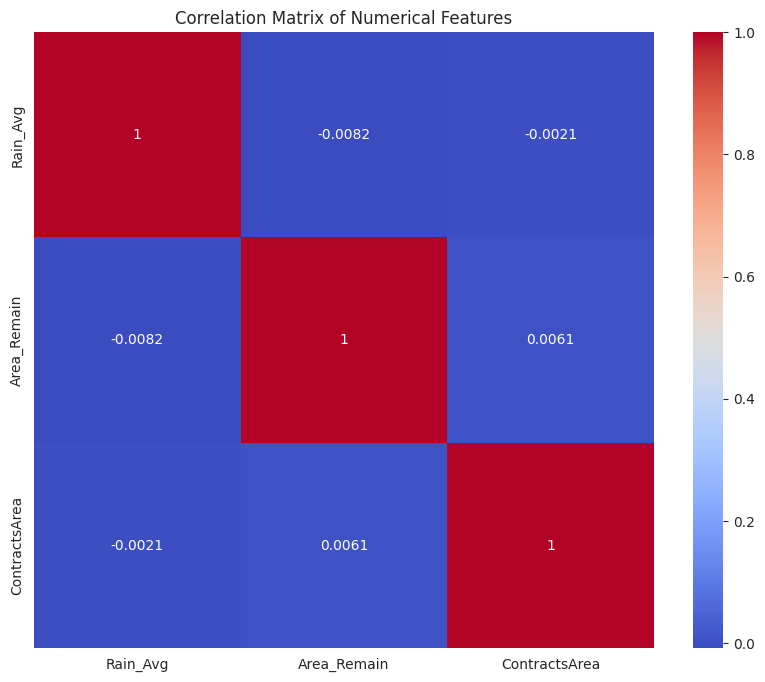

In [31]:
# Compute correlation matrix
corr_matrix = train_data[[ 'Rain_Avg', 'Area_Remain', 'ContractsArea']].corr()

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix of Numerical Features')
plt.show()


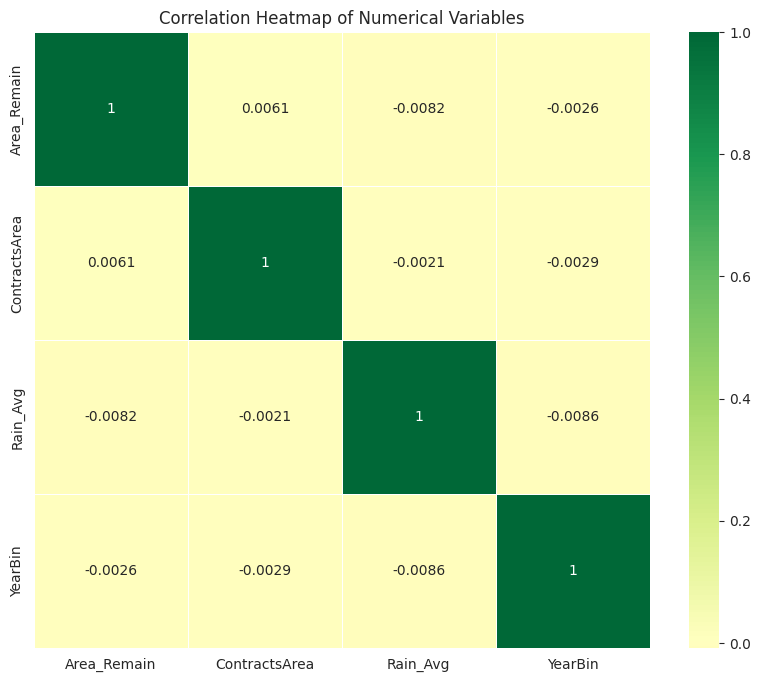

In [32]:
# Select only numerical columns
numerical_data = train_data.select_dtypes(include=['int64', 'float64'])

# Compute correlation matrix
cor_matrix = numerical_data.corr()

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(cor_matrix,
            annot=True,
            cmap='RdYlGn',  # Similar to green-white-red
            center=0,
            linewidths=0.5,
            square=True)
plt.title("Correlation Heatmap of Numerical Variables")
plt.show()


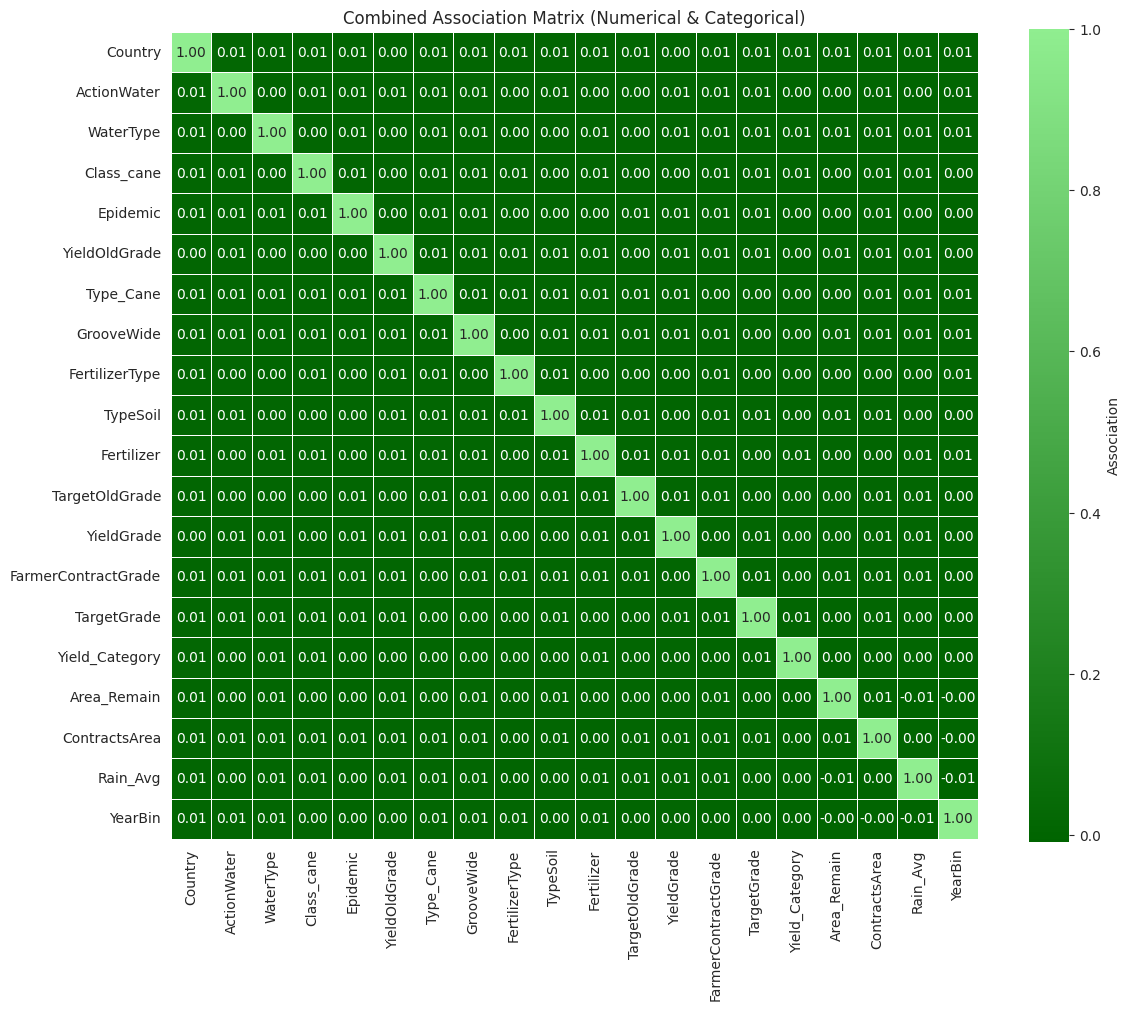

In [33]:
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# Cramér's V for categorical–categorical
def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    return np.sqrt(phi2 / min(k - 1, r - 1))

# Correlation Ratio (η²) for categorical–numerical
def correlation_ratio(categories, measurements):
    fcat, _ = pd.factorize(categories)
    cat_num = np.max(fcat) + 1
    y_avg_array = np.zeros(cat_num)
    n_array = np.zeros(cat_num)

    for i in range(cat_num):
        cat_measures = measurements[np.argwhere(fcat == i).flatten()]
        n_array[i] = len(cat_measures)
        y_avg_array[i] = np.mean(cat_measures) if len(cat_measures) > 0 else 0

    y_total_avg = np.sum(y_avg_array * n_array) / np.sum(n_array)
    numerator = np.sum(n_array * (y_avg_array - y_total_avg)**2)
    denominator = np.sum((measurements - y_total_avg)**2)
    return np.sqrt(numerator / denominator) if denominator != 0 else 0



# Detect variable types
cat_vars = train_data.select_dtypes(include=['object', 'category']).columns
num_vars = train_data.select_dtypes(include=['int64', 'float64']).columns
all_vars = list(cat_vars) + list(num_vars)

# Create empty association matrix
assoc_matrix = pd.DataFrame(index=all_vars, columns=all_vars, dtype=float)

# Compute association values
for col1 in all_vars:
    for col2 in all_vars:
        if col1 == col2:
            assoc_matrix.loc[col1, col2] = 1.0
        elif col1 in num_vars and col2 in num_vars:
            assoc_matrix.loc[col1, col2] = df[[col1, col2]].corr().iloc[0, 1]
        elif col1 in cat_vars and col2 in cat_vars:
            assoc_matrix.loc[col1, col2] = cramers_v(df[col1], df[col2])
        else:
            if col1 in cat_vars and col2 in num_vars:
                assoc_matrix.loc[col1, col2] = correlation_ratio(df[col1], df[col2].values)
            else:
                assoc_matrix.loc[col1, col2] = correlation_ratio(df[col2], df[col1].values)

# ==== Custom Green to Light Green Color Map ====
green_cmap = mcolors.LinearSegmentedColormap.from_list(
    "green_lightgreen", ["darkgreen", "lightgreen"]
)

# ==== Plot Heatmap ====
plt.figure(figsize=(12, 10))
sns.heatmap(
    assoc_matrix.astype(float),
    annot=True,
    fmt=".2f",
    cmap=green_cmap,
    square=True,
    linewidths=0.5,
    cbar_kws={'label': 'Association'}
)
plt.title("Combined Association Matrix (Numerical & Categorical)")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


### Factor analysis

In [34]:
# Remove 'Yield_Category' column
df1 = train_data.drop(columns=['Yield_Category'])

In [35]:
# Convert character columns to category type
cat_cols = df1.select_dtypes(include=['object']).columns
df1[cat_cols] = df1[cat_cols].apply(lambda x: x.astype('category'))

In [36]:
# Apply FAMD (Factor Analysis of Mixed Data) using the prince library
famd = prince.FAMD(n_components=5, random_state=123)
famd = famd.fit(df1)

/usr/local/lib/python3.11/dist-packages/prince/mfa.py:98: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[-0.00470754 -0.00470754  0.00533539 ...  0.00198775  0.00198775
 -0.0013599 ]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  X.loc[:, num] = (X.loc[:, num] - X.loc[:, num].mean()).apply(normalize, axis='rows')


In [37]:
# View summary (Explained variance of each dimension)
explained_variance = famd.explained_inertia_
print("Explained Inertia (Variance):", explained_variance)

Explained Inertia (Variance): [0.07257216 0.07221329 0.07133521 0.07075206 0.02544146]


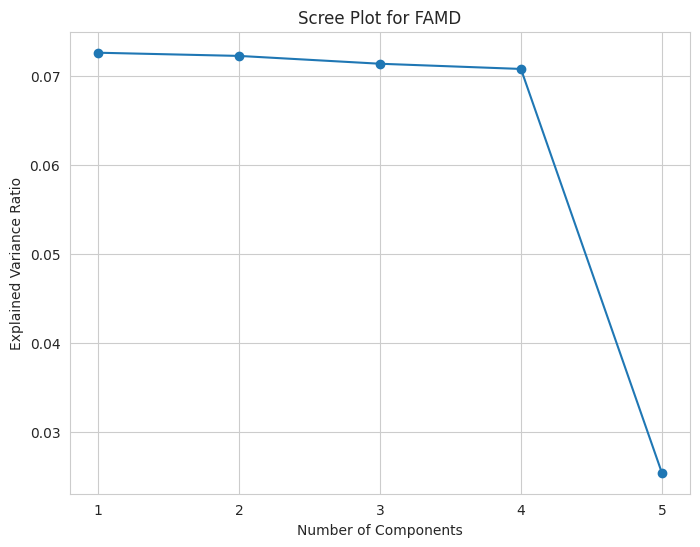

In [38]:
# Scree Plot
import matplotlib.pyplot as plt

# Get explained variance ratios
explained_variance_ratios = famd.explained_inertia_

# Create scree plot
plt.figure(figsize=(8, 6))
plt.plot(range(1, len(explained_variance_ratios) + 1), explained_variance_ratios, marker='o')
plt.title('Scree Plot for FAMD')
plt.xlabel('Number of Components')
plt.ylabel('Explained Variance Ratio')
plt.xticks(range(1, len(explained_variance_ratios) + 1))
plt.grid(True)
plt.show()